# PyQuil Error Mitigation Workflow

This notebook shows a small, beginner-friendly example of quantum error mitigation using PyQuil.

The main idea is simple: first we see what the perfect answer should look like, then we add noise, and then we try simple methods to reduce the effect of that noise.

| Step | What we do |
|---|---|
| Step 1 | Create a Bell-state circuit and calculate the ideal $\langle ZZ \rangle$ value |
| Step 2 | Add measurement noise and see how the answer becomes worse |
| Step 3 | Use a confusion matrix to correct measurement noise |
| Step 4 | Repeat CNOT gates to make noisier versions of the same circuit |
| Step 5 | Use those noisy results to estimate the zero-noise answer |

PyQuil is used to build the quantum circuit. NumPy is used for simple math such as sampling counts, solving matrices, and fitting a straight line.

## Cell 1: Imports and Constants

This cell loads the Python libraries and sets a few values that will be reused later.

Important terms:

- `SHOTS` means how many times we pretend to measure the circuit.
- `READOUT_ERROR` means the measurement result can be read incorrectly.
- `CNOT_GATE_ERROR` means each CNOT gate can add a little noise.
- For $ZZ$, `00` and `11` mean the qubits match, so they count as `+1`. `01` and `10` mean they differ, so they count as `-1`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from pyquil import Program
from pyquil.gates import CNOT, H
from pyquil.simulation.tools import program_unitary
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


BITSTRINGS = ["00", "01", "10", "11"]
SHOTS = 8192
SEED = 7

READOUT_ERROR = 0.08
CNOT_GATE_ERROR = 0.02

np.set_printoptions(precision=4, suppress=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D5DAE0",
    "axes.labelcolor": "#263238",
    "xtick.color": "#37474F",
    "ytick.color": "#37474F",
    "text.color": "#263238",
    "font.size": 10,
})


## Cell 2: Helper Functions

This cell defines small reusable functions. They make the later cells shorter and easier to read.

What the helpers do:

- `bell_program` creates the Bell-state circuit.
- `state_probabilities` gives the ideal probabilities of seeing `00`, `01`, `10`, or `11`.
- `sample_counts` converts probabilities into measurement counts.
- `zz_from_counts` computes $\langle ZZ \rangle$ from counts.
- `confusion_matrix` describes how measurement errors mix up the true answers.
- `mitigate_counts` tries to undo measurement errors.
- `simple_gate_noise` adds a simple gate-noise model for the ZNE example.

In [3]:
def bell_program(cnot_count=1):
    program = Program(H(0))
    for _ in range(cnot_count):
        program += CNOT(0, 1)
    return program


def state_probabilities(program):
    unitary = program_unitary(program, n_qubits=2)
    initial_state = np.array([1, 0, 0, 0], dtype=complex)
    state = unitary @ initial_state
    probabilities = np.abs(state) ** 2
    return {bitstring: float(prob) for bitstring, prob in zip(BITSTRINGS, probabilities)}


def sample_counts(probabilities, shots=SHOTS, seed=SEED):
    rng = np.random.default_rng(seed)
    probs = np.array([probabilities.get(bitstring, 0.0) for bitstring in BITSTRINGS])
    samples = rng.multinomial(shots, probs / probs.sum())
    return dict(zip(BITSTRINGS, samples.tolist()))


def zz_from_counts(counts):
    shots = sum(counts.values())
    same = counts.get("00", 0) + counts.get("11", 0)
    different = counts.get("01", 0) + counts.get("10", 0)
    return (same - different) / shots


def zz_from_probabilities(probabilities):
    same = probabilities.get("00", 0.0) + probabilities.get("11", 0.0)
    different = probabilities.get("01", 0.0) + probabilities.get("10", 0.0)
    return same - different


def readout_probability(observed, true, error):
    probability = 1.0
    for observed_bit, true_bit in zip(observed, true):
        probability *= (1 - error) if observed_bit == true_bit else error
    return probability


def confusion_matrix(error):
    return np.array([
        [readout_probability(observed, true, error) for true in BITSTRINGS]
        for observed in BITSTRINGS
    ])


def apply_bit_flip_noise(probabilities, error):
    vector = np.array([probabilities.get(bitstring, 0.0) for bitstring in BITSTRINGS])
    noisy_vector = confusion_matrix(error) @ vector
    return {bitstring: float(prob) for bitstring, prob in zip(BITSTRINGS, noisy_vector)}


def mitigate_counts(counts, error=READOUT_ERROR):
    shots = sum(counts.values())
    observed = np.array([counts.get(bitstring, 0) / shots for bitstring in BITSTRINGS])
    mitigated = np.linalg.solve(confusion_matrix(error), observed)

    mitigated = np.clip(mitigated, 0.0, 1.0)
    mitigated = mitigated / mitigated.sum()

    return {bitstring: float(prob) for bitstring, prob in zip(BITSTRINGS, mitigated)}


def simple_gate_noise(probabilities, cnot_count, error=CNOT_GATE_ERROR):
    noisy_probabilities = probabilities
    for _ in range(cnot_count):
        noisy_probabilities = apply_bit_flip_noise(noisy_probabilities, error)
    return noisy_probabilities


def print_table(rows, headers):
    widths = [len(header) for header in headers]
    for row in rows:
        for index, value in enumerate(row):
            widths[index] = max(widths[index], len(str(value)))

    line = " | ".join(header.ljust(widths[index]) for index, header in enumerate(headers))
    rule = "-+-".join("-" * width for width in widths)
    print(line)
    print(rule)
    for row in rows:
        print(" | ".join(str(value).ljust(widths[index]) for index, value in enumerate(row)))

## Visual Guide: The Full Idea

This picture gives a simple map of the notebook. We start with a clean Bell circuit, add noise, then use two correction ideas: readout mitigation and ZNE.

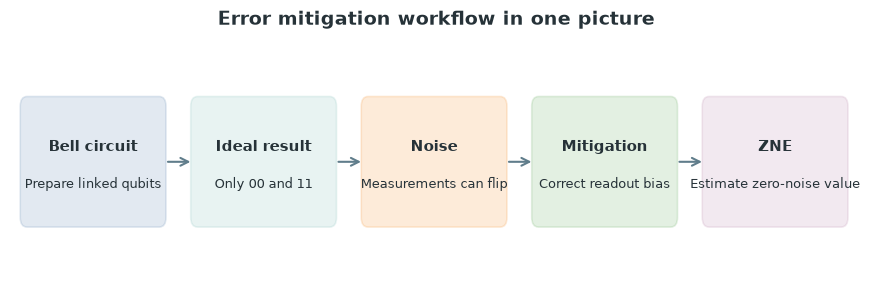

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.axis("off")

steps = [
    (0.2, "Bell circuit", "Prepare linked qubits"),
    (2.2, "Ideal result", "Only 00 and 11"),
    (4.2, "Noise", "Measurements can flip"),
    (6.2, "Mitigation", "Correct readout bias"),
    (8.2, "ZNE", "Estimate zero-noise value"),
]
colors = ["#4C78A8", "#72B7B2", "#F58518", "#54A24B", "#B279A2"]

for index, (x, title, subtitle) in enumerate(steps):
    box = FancyBboxPatch(
        (x, 0.55), 1.55, 0.9,
        boxstyle="round,pad=0.08,rounding_size=0.08",
        linewidth=1.2, edgecolor=colors[index], facecolor=colors[index], alpha=0.16
    )
    ax.add_patch(box)
    ax.text(x + 0.775, 1.12, title, ha="center", va="center", weight="bold", fontsize=11)
    ax.text(x + 0.775, 0.82, subtitle, ha="center", va="center", fontsize=9)
    if index < len(steps) - 1:
        arrow = FancyArrowPatch((x + 1.62, 1.0), (x + 1.95, 1.0), arrowstyle="->", mutation_scale=14, color="#607D8B", linewidth=1.5)
        ax.add_patch(arrow)

ax.set_title("Error mitigation workflow in one picture", fontsize=14, weight="bold", pad=10)
plt.show()

## Cell 3: Bell Circuit, Ideal Counts, and $\langle ZZ \rangle$

This cell creates the Bell-state circuit.

A Bell state is a two-qubit state where the qubits are perfectly linked. In this example, the ideal result should only give `00` and `11`.

After making the circuit, we calculate ideal probabilities, sample counts, and compute $\langle ZZ \rangle$. For the perfect Bell state, the expected value is `1`.

In [5]:
bell = bell_program(cnot_count=1)
ideal_probabilities = state_probabilities(bell)
ideal_counts = sample_counts(ideal_probabilities, seed=SEED)
ideal_zz = zz_from_counts(ideal_counts)

print("Bell circuit:")
print(bell)
print("Ideal probabilities:", ideal_probabilities)
print("Ideal counts:", ideal_counts)
print("Ideal <ZZ> from counts:", ideal_zz)

Bell circuit:
H 0
CNOT 0 1

Ideal probabilities: {'00': 0.4999999999999999, '01': 0.0, '10': 0.0, '11': 0.4999999999999999}
Ideal counts: {'00': 4090, '01': 0, '10': 0, '11': 4102}
Ideal <ZZ> from counts: 1.0


## Cell 4: Add Simple Readout Noise

This cell adds measurement noise.

Readout noise means the quantum state may be correct, but the measurement can be reported wrongly. For example, a true `0` may be read as `1`.

Here each measured bit has an 8% chance of being flipped. We then compute the noisy $\langle ZZ \rangle$ value and compare it with the ideal result.

In [6]:
readout_noisy_probabilities = apply_bit_flip_noise(ideal_probabilities, READOUT_ERROR)
readout_noisy_counts = sample_counts(readout_noisy_probabilities, seed=SEED)
raw_readout_noisy_zz = zz_from_counts(readout_noisy_counts)

print("Ideal counts:", ideal_counts)
print("Readout-noisy probabilities:", readout_noisy_probabilities)
print("Readout-noisy counts:", readout_noisy_counts)
print("Raw readout-noisy <ZZ>:", raw_readout_noisy_zz)

Ideal counts: {'00': 4090, '01': 0, '10': 0, '11': 4102}
Readout-noisy probabilities: {'00': 0.4263999999999999, '01': 0.07359999999999998, '10': 0.07359999999999998, '11': 0.4263999999999999}
Readout-noisy counts: {'00': 3487, '01': 584, '10': 585, '11': 3536}
Raw readout-noisy <ZZ>: 0.714599609375


## Visual: Ideal Counts vs Noisy Counts

This bar chart shows what noise does to the measurement results. In the ideal case, nearly all counts are in `00` and `11`. After readout noise, some counts leak into `01` and `10`, which lowers $\langle ZZ \rangle$.

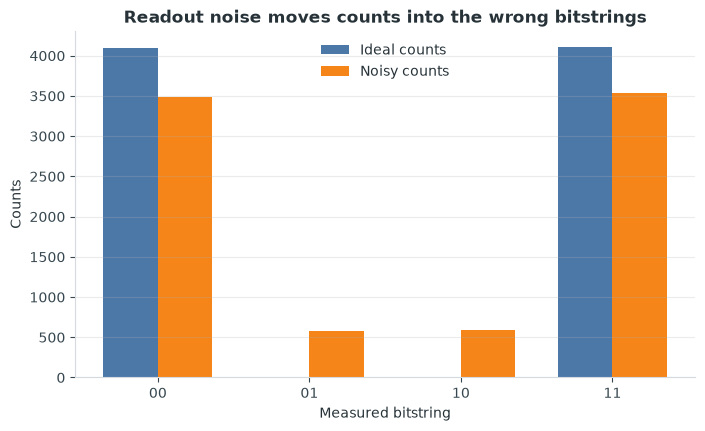

In [7]:
x = np.arange(len(BITSTRINGS))
width = 0.36
ideal_values = [ideal_counts.get(bitstring, 0) for bitstring in BITSTRINGS]
noisy_values = [readout_noisy_counts.get(bitstring, 0) for bitstring in BITSTRINGS]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, ideal_values, width, label="Ideal counts", color="#4C78A8")
ax.bar(x + width / 2, noisy_values, width, label="Noisy counts", color="#F58518")
ax.set_xticks(x)
ax.set_xticklabels(BITSTRINGS)
ax.set_xlabel("Measured bitstring")
ax.set_ylabel("Counts")
ax.set_title("Readout noise moves counts into the wrong bitstrings", weight="bold")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
plt.show()

## Cell 5: Confusion Matrix and Readout Mitigation

This cell tries to correct measurement noise.

The confusion matrix is a table that says how often each true answer is reported as each measured answer. For example, it tells us how often true `00` is still read as `00`, or accidentally read as `01`, `10`, or `11`.

Readout mitigation uses this table to work backward from noisy counts and estimate what the counts were before measurement mistakes.

In [8]:
readout_matrix = confusion_matrix(READOUT_ERROR)
mitigated_probabilities = mitigate_counts(readout_noisy_counts)
readout_mitigated_zz = zz_from_probabilities(mitigated_probabilities)

print("Rows: observed 00, 01, 10, 11")
print("Cols: true     00, 01, 10, 11")
print(readout_matrix)
print("Mitigated probabilities:", mitigated_probabilities)
print("Raw readout-noisy <ZZ>:", raw_readout_noisy_zz)
print("Readout-mitigated <ZZ>:", readout_mitigated_zz)

Rows: observed 00, 01, 10, 11
Cols: true     00, 01, 10, 11
[[0.8464 0.0736 0.0736 0.0064]
 [0.0736 0.8464 0.0064 0.0736]
 [0.0736 0.0064 0.8464 0.0736]
 [0.0064 0.0736 0.0736 0.8464]]
Mitigated probabilities: {'00': 0.49646217754931565, '01': 0.0, '10': 0.0, '11': 0.5035378224506842}
Raw readout-noisy <ZZ>: 0.714599609375
Readout-mitigated <ZZ>: 0.9999999999999999


## Visual: Readout Confusion Matrix

This heatmap shows the measurement-error table. Bright diagonal entries mean the result is usually read correctly. Smaller off-diagonal entries show the chance of reading the wrong bitstring.

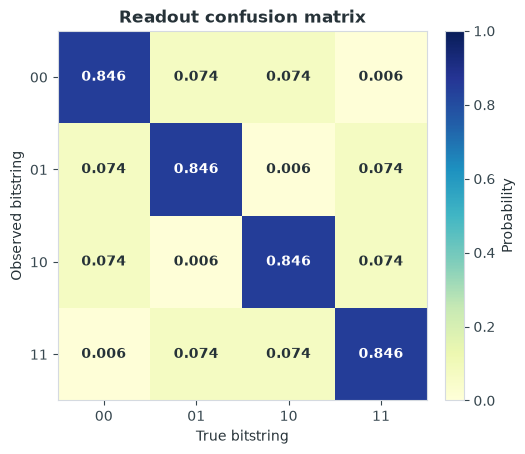

In [9]:
fig, ax = plt.subplots(figsize=(5.8, 4.8))
image = ax.imshow(readout_matrix, cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(BITSTRINGS)))
ax.set_yticks(np.arange(len(BITSTRINGS)))
ax.set_xticklabels(BITSTRINGS)
ax.set_yticklabels(BITSTRINGS)
ax.set_xlabel("True bitstring")
ax.set_ylabel("Observed bitstring")
ax.set_title("Readout confusion matrix", weight="bold")

for row in range(len(BITSTRINGS)):
    for col in range(len(BITSTRINGS)):
        value = readout_matrix[row, col]
        text_color = "white" if value > 0.5 else "#263238"
        ax.text(col, row, f"{value:.3f}", ha="center", va="center", color=text_color, weight="bold")

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Probability")
plt.show()

## Cell 6: CNOT Folding at Noise Scales 1, 3, and 5

This cell creates noisier versions of the same circuit.

CNOT folding means we replace one CNOT with 1, 3, or 5 CNOT gates. This works because CNOT cancels itself in pairs, so an odd number of CNOTs still acts like one CNOT in the ideal case:

$$\text{CNOT}^1 = \text{CNOT}, \qquad \text{CNOT}^3 = \text{CNOT}, \qquad \text{CNOT}^5 = \text{CNOT}.$$

So the perfect circuit is still logically the same, but the real noisy circuit has more chances to make mistakes. This gives us different noise levels for the ZNE step.

In [10]:
scale_factors = np.array([1, 3, 5])
zne_rows = []
zne_values = []

for scale in scale_factors:
    folded_program = bell_program(cnot_count=int(scale))
    folded_ideal_probabilities = state_probabilities(folded_program)
    folded_noisy_probabilities = simple_gate_noise(folded_ideal_probabilities, cnot_count=int(scale))
    folded_noisy_counts = sample_counts(folded_noisy_probabilities, seed=SEED + int(scale))
    folded_zz = zz_from_counts(folded_noisy_counts)

    zne_values.append(float(folded_zz))
    zne_rows.append([int(scale), folded_noisy_counts, round(float(folded_zz), 6)])

print_table(zne_rows, headers=["CNOT count / scale", "Noisy counts", "Noisy <ZZ>"])

CNOT count / scale | Noisy counts                                   | Noisy <ZZ>
-------------------+------------------------------------------------+-----------
1                  | {'00': 3882, '01': 156, '10': 179, '11': 3975} | 0.918213  
3                  | {'00': 3522, '01': 461, '10': 481, '11': 3728} | 0.77002   
5                  | {'00': 3351, '01': 698, '10': 707, '11': 3436} | 0.656982  


## Cell 7: Linear ZNE Fit

This cell estimates what the answer would be with zero gate noise.

ZNE means Zero-Noise Extrapolation. The idea is:

1. Run the circuit with different noise levels.
2. Look at how the answer changes as noise increases.
3. Fit a simple line through those points.
4. Extend the line backward to noise level `0`.

If the fitted line is

$$f(s) = ms + b,$$

then the zero-noise estimate is the intercept:

$$f(0) = b.$$

In [11]:
zne_values = np.array(zne_values)
slope, intercept = np.polyfit(scale_factors, zne_values, deg=1)
zne_estimate = float(intercept)

print("Scale factors:", scale_factors.tolist())
print("Measured noisy <ZZ> values:", [round(float(value), 6) for value in zne_values])
print("Linear fit: <ZZ>(scale) =", round(float(slope), 6), "* scale +", round(float(intercept), 6))
print("Zero-noise estimate from ZNE:", round(zne_estimate, 6))

Scale factors: [1, 3, 5]
Measured noisy <ZZ> values: [0.918213, 0.77002, 0.656982]
Linear fit: <ZZ>(scale) = -0.065308 * scale + 0.977661
Zero-noise estimate from ZNE: 0.977661


## Visual: ZNE Line Fit

This plot shows the noisy $\langle ZZ \rangle$ values at scale factors `1`, `3`, and `5`. The dashed line is the fitted trend. The value where the line reaches scale `0` is the zero-noise estimate.

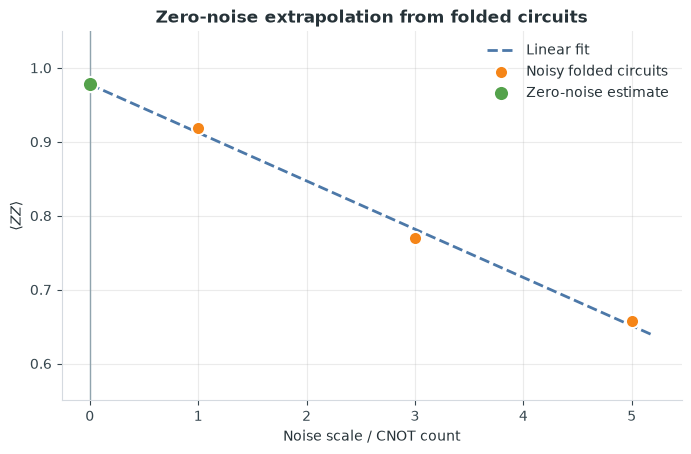

In [12]:
fit_x = np.linspace(0, 5.2, 100)
fit_y = slope * fit_x + intercept

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(fit_x, fit_y, linestyle="--", color="#4C78A8", linewidth=2, label="Linear fit")
ax.scatter(scale_factors, zne_values, s=90, color="#F58518", edgecolor="white", linewidth=1.5, label="Noisy folded circuits", zorder=3)
ax.scatter([0], [zne_estimate], s=120, color="#54A24B", edgecolor="white", linewidth=1.5, label="Zero-noise estimate", zorder=4)
ax.axvline(0, color="#90A4AE", linewidth=1)
ax.set_xlabel("Noise scale / CNOT count")
ax.set_ylabel(r"$\langle ZZ \rangle$")
ax.set_title("Zero-noise extrapolation from folded circuits", weight="bold")
ax.set_ylim(0.55, 1.05)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25)
plt.show()

## Cell 8: Final Comparison Table

This cell puts the important results in one table.

The table helps compare:

- the perfect answer,
- the noisy answer,
- the answer after measurement-error correction,
- the ZNE estimate for reducing gate-noise effects.

In [13]:
comparison_rows = [
    ["Ideal Bell state", round(ideal_zz, 6), "No noise; counts sampled from ideal probabilities"],
    ["Raw readout-noisy", round(raw_readout_noisy_zz, 6), "Readout bit-flip noise only"],
    ["Readout-mitigated", round(readout_mitigated_zz, 6), "Confusion-matrix correction applied"],
    ["ZNE estimate", round(zne_estimate, 6), "Linear extrapolation using CNOT scales 1, 3, 5"],
]

print_table(comparison_rows, headers=["Case", "<ZZ>", "Meaning"])

Case              | <ZZ>     | Meaning                                          
------------------+----------+--------------------------------------------------
Ideal Bell state  | 1.0      | No noise; counts sampled from ideal probabilities
Raw readout-noisy | 0.7146   | Readout bit-flip noise only                      
Readout-mitigated | 1.0      | Confusion-matrix correction applied              
ZNE estimate      | 0.977661 | Linear extrapolation using CNOT scales 1, 3, 5   


## Visual: Final $\langle ZZ \rangle$ Comparison

This final chart compares the main answers. Higher is better here because the ideal Bell-state value is $1$. The noisy value drops, while mitigation and ZNE move the result back toward the ideal value.

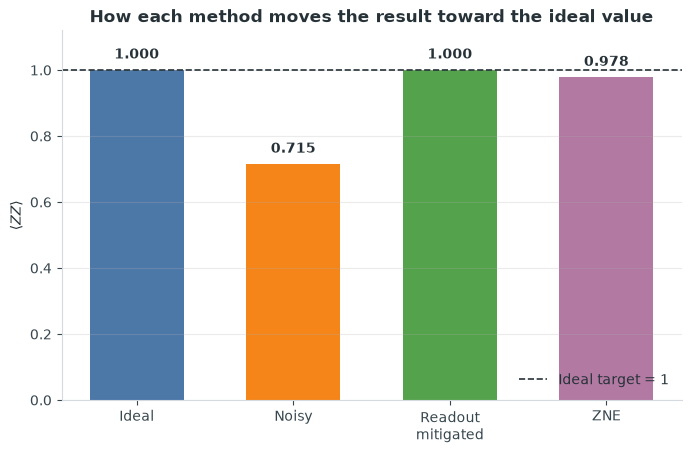

In [14]:
labels = ["Ideal", "Noisy", "Readout\nmitigated", "ZNE"]
values = [ideal_zz, raw_readout_noisy_zz, readout_mitigated_zz, zne_estimate]
colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(labels, values, color=colors, width=0.6)
ax.axhline(1.0, color="#263238", linestyle="--", linewidth=1.2, label="Ideal target = 1")
ax.set_ylim(0, 1.12)
ax.set_ylabel(r"$\langle ZZ \rangle$")
ax.set_title("How each method moves the result toward the ideal value", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, loc="lower right")

for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.025, f"{value:.3f}", ha="center", va="bottom", weight="bold")

plt.show()